## Model Training Tracked with Mlflow


In [1]:
# check if everything here is needed
import mlflow
from mlflow import keras
from mlflow.models import infer_signature

from helper_functions import * 

import matplotlib.pyplot as plt
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.models import load_model

# Extract features from the test data
from sklearn.metrics import explained_variance_score, mean_absolute_error, r2_score, mean_squared_error

from mlflow.models import infer_signature

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

2023-11-29 18:18:26.095039: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-11-29 18:18:26.095069: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-11-29 18:18:26.095098: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-11-29 18:18:26.101661: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  NVIDIA GeForce GTX 1060 6GB, compute capability 6.1
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


2023-11-29 18:18:27.937490: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-11-29 18:18:27.942446: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-11-29 18:18:27.942611: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## Data Prep

In [2]:
def data_prep(lstm_data):
    # Data preperation
    lstm_data = lstm_data.drop(columns=['open_price', 'high', 'low'], axis=1)

    lstm_data = process_timestamp(lstm_data, fill=True)
    lstm_data = add_feature_date(lstm_data)
    lstm_data = add_holiday_feature(lstm_data)
    lstm_data = apply_cyclic_encoding(lstm_data, columms=['hour', 'day_of_week', 'month'])
    lstm_data = apply_day_of_month_encoding(lstm_data)
    lstm_data = normalize_year(lstm_data) # has to be updated yearly 
    lstm_data['close_price_true'] =  lstm_data['close_price']
    lstm_data = apply_log_scaler(lstm_data, columns=['close_price', 'volume', 'count'])
    lstm_data = add_feature_lag(lstm_data, lags=[1,4,6,12,168])
    lstm_data = simple_moving_average(lstm_data, window_sizes=[6,12], columns=['close_price'])
    lstm_data = exponential_moving_average(lstm_data, span_sizes=[6,12], columns=['close_price'])

    lstm_data = lstm_data.drop(columns=['symbol_id', 'hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)

    lstm_data = lstm_data.dropna()

    return lstm_data

In [3]:
# Data preperation
file_path = 'kraken_ohlc_hour_count.csv'
lstm_data = pd.read_csv(file_path)
lstm_data = data_prep(lstm_data)
lstm_data.head(10)

,bucket,close_price,volume,count,is_weekend,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,...,close_price_true,close_lag1,close_lag4,close_lag6,close_lag12,close_lag168,sma_6_close_price,sma_12_close_price,ema_6_close_price,ema_12_close_price
168,2015-08-14 14:00:00+00:00,1.099205,3.931159,1.098612,0,0,-8.660254e-01,-0.500000,-0.900969,-0.433884,...,2.00178,1.131402,1.131402,1.093533,1.085189,1.386294,1.119724,1.099312,1.113550,1.097994
169,2015-08-14 15:00:00+00:00,1.099205,0.000000,0.000000,0,0,-7.071068e-01,-0.707107,-0.900969,-0.433884,...,2.00178,1.099205,1.131402,1.093533,1.071584,1.386294,1.120670,1.101614,1.109451,1.098180
170,2015-08-14 16:00:00+00:00,1.073096,2.638756,0.693147,0,0,-5.000000e-01,-0.866025,-0.900969,-0.433884,...,1.92442,1.099205,1.131402,1.131402,1.071584,1.386294,1.110952,1.101740,1.099064,1.094321
171,2015-08-14 17:00:00+00:00,1.033184,5.380558,2.079442,0,0,-2.588190e-01,-0.965926,-0.900969,-0.433884,...,1.81000,1.073096,1.131402,1.131402,1.071584,1.386294,1.094583,1.098540,1.080241,1.084915
172,2015-08-14 18:00:00+00:00,1.057790,5.303305,1.386294,0,0,-1.836970e-16,-1.000000,-0.900969,-0.433884,...,1.88000,1.033184,1.099205,1.131402,1.071584,1.386294,1.082314,1.097391,1.073827,1.080742
173,2015-08-14 19:00:00+00:00,1.064711,5.772507,2.772589,0,0,2.588190e-01,-0.965926,-0.900969,-0.433884,...,1.90000,1.057790,1.099205,1.131402,1.093533,1.386294,1.071199,1.094989,1.071222,1.078276
174,2015-08-14 20:00:00+00:00,1.108563,7.606771,3.871201,0,0,5.000000e-01,-0.866025,-0.900969,-0.433884,...,2.03000,1.064711,1.073096,1.099205,1.093533,1.386294,1.072758,1.096241,1.081891,1.082935
175,2015-08-14 21:00:00+00:00,1.095273,6.589037,2.397895,0,0,7.071068e-01,-0.707107,-0.900969,-0.433884,...,1.99000,1.108563,1.033184,1.099205,1.093533,1.386294,1.072103,1.096386,1.085714,1.084834
176,2015-08-14 22:00:00+00:00,1.047319,5.667998,2.397895,0,0,8.660254e-01,-0.500000,-0.900969,-0.433884,...,1.85000,1.095273,1.057790,1.073096,1.131402,1.386294,1.067807,1.089379,1.074744,1.079062
177,2015-08-14 23:00:00+00:00,1.029619,6.906667,2.995732,0,0,9.659258e-01,-0.258819,-0.900969,-0.433884,...,1.80000,1.047319,1.064711,1.033184,1.131402,1.386294,1.067213,1.080898,1.061851,1.071456


In [4]:
lstm_test = lstm_data.iloc[int(len(lstm_data)*0.99):] 
lstm_data = lstm_data.iloc[:int(len(lstm_data)*0.99)]

In [5]:
len(lstm_test)

713

In [6]:
len(lstm_data)

70527

In [7]:
def create_sequences_np(data, features, lookback, datatype=np.float16):
    data_array = data[features].to_numpy()
    X, y = [], []
    for i in range(lookback, len(data_array)):
        X.append(data_array[i-lookback:i])
        y.append(data_array[i, data.columns.get_loc('close_price')])
    return np.array(X).astype(datatype), np.array(y).astype(datatype)

features = ['is_holiday', 'close_price', 'volume', 'is_weekend', 'count',
             'hour_cos', 'hour_sin', 'day_of_week_cos', 
            'day_of_week_sin', 'month_cos', 'month_sin', 
            'day_of_month_sin', 'day_of_month_cos', 'year_normalized', 'close_lag12', 'close_lag168', 'ema_6_close_price', 'ema_12_close_price']

lookback = 24
X, y = create_sequences_np(lstm_data, features, lookback)

## Model Training

In [8]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam

n_features = len(features)  # Number of features used
epochs = 50
units_lstm_1 = n_features * lookback
units_lstm_2 = n_features * lookback
dropout_layer_1 = 0.2
dropout_layer_2 = 0.2

print(units_lstm_1)
print(units_lstm_2)

return_sequences_lstm_1 = True
return_sequences_lstm_2 = False

dense_units = 1 

optimizer = 'adam'
loss = 'mean_absolute_error'

training_validation_split = 0.8

batch_size = 16

# LSTM model
model = Sequential()
model.add(LSTM(units=units_lstm_1,return_sequences=return_sequences_lstm_1, input_shape=(lookback, n_features))) # 1
model.add(Dropout(dropout_layer_1))
model.add(LSTM(units=units_lstm_2, return_sequences=return_sequences_lstm_2)) # 2
model.add(Dropout(dropout_layer_2))
model.add(Dense(units=dense_units))

# Adam(learning_rate=0.001)

model.compile(optimizer='adam', loss=loss, metrics=['mean_absolute_error', 'mean_squared_error'])

# split point at 20 percent 
split_idx = int(len(X) * training_validation_split)

# validation set with the last 20 percent of the dataset 
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(model.summary())

# maybe 43 epochs seems to have a good loss 
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))


432
432


2023-11-29 18:18:30.938617: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-11-29 18:18:30.938836: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-11-29 18:18:30.938960: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 432)           779328    
                                                                 
 dropout (Dropout)           (None, 24, 432)           0         
                                                                 
 lstm_1 (LSTM)               (None, 432)               1494720   
                                                                 
 dropout_1 (Dropout)         (None, 432)               0         
                                                                 
 dense (Dense)               (None, 1)                 433       
                                                                 
Total params: 2274481 (8.68 MB)
Trainable params: 2274481 (8.68 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/50


2023-11-29 18:18:35.237507: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2023-11-29 18:18:36.421736: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f868c175790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-11-29 18:18:36.421760: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1060 6GB, Compute Capability 6.1
2023-11-29 18:18:36.427640: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-11-29 18:18:36.541602: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3526/3526 [==============================] - 46s 12ms/step - loss: 0.2068 - mean_absolute_error: 0.2068 - mean_squared_error: 0.0900 - val_loss: 0.0871 - val_mean_absolute_error: 0.0871 - val_mean_squared_error: 0.0109
Epoch 2/50
3526/3526 [==============================] - 41s 12ms/step - loss: 0.1571 - mean_absolute_error: 0.1571 - mean_squared_error: 0.0433 - val_loss: 0.1722 - val_mean_absolute_error: 0.1722 - val_mean_squared_error: 0.0326
Epoch 3/50
3526/3526 [==============================] - 41s 12ms/step - loss: 0.1397 - mean_absolute_error: 0.1397 - mean_squared_error: 0.0343 - val_loss: 0.0716 - val_mean_absolute_error: 0.0716 - val_mean_squared_error: 0.0065
Epoch 4/50
3526/3526 [==============================] - 41s 12ms/step - loss: 0.1306 - mean_absolute_error: 0.1306 - mean_squared_error: 0.0306 - val_loss: 0.0658 - val_mean_absolute_error: 0.0658 - val_mean_squared_error: 0.0055
Epoch 5/50
3526/3526 [==============================] - 41s 12ms/step - loss: 0.1220 - mean

In [9]:
## load non-training data: + 12hour lookback 

test_file_path = 'kraken_ohlc_hour_count_unseen.csv'

# Data preperation
#test_lstm = data_prep(test_file_path)
#original_lstm_test = pd.read_csv(test_file_path) 

lstm_test.head(100)

,bucket,close_price,volume,count,is_weekend,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,...,close_price_true,close_lag1,close_lag4,close_lag6,close_lag12,close_lag168,sma_6_close_price,sma_12_close_price,ema_6_close_price,ema_12_close_price
70695,2023-08-31 05:00:00+00:00,7.440998,4.598232,4.787492,0,0,2.588190e-01,0.965926,-0.900969,0.433884,...,1703.45,7.439700,7.438484,7.441977,7.439318,7.423652,7.439249,7.440081,7.439855,7.440494
70696,2023-08-31 06:00:00+00:00,7.441584,5.615610,5.198497,0,0,6.123234e-17,1.000000,-0.900969,0.433884,...,1704.45,7.440998,7.438948,7.439242,7.441103,7.424332,7.439640,7.440122,7.440349,7.440662
70697,2023-08-31 07:00:00+00:00,7.442487,5.063637,4.820282,0,0,-2.588190e-01,0.965926,-0.900969,0.433884,...,1705.99,7.441584,7.438125,7.438484,7.439929,7.423813,7.440307,7.440335,7.440960,7.440942
70698,2023-08-31 08:00:00+00:00,7.442469,7.088198,5.463832,0,0,-5.000000e-01,0.866025,-0.900969,0.433884,...,1705.96,7.442487,7.439700,7.438948,7.440880,7.422738,7.440894,7.440467,7.441391,7.441177
70699,2023-08-31 09:00:00+00:00,7.441326,4.171881,4.700480,0,0,-7.071068e-01,0.707107,-0.900969,0.433884,...,1704.01,7.442469,7.440998,7.438125,7.441115,7.419285,7.441427,7.440485,7.441373,7.441200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70790,2023-09-04 04:00:00+00:00,7.401927,3.225643,4.605170,0,1,5.000000e-01,0.866025,1.000000,0.000000,...,1638.14,7.401482,7.399783,7.400370,7.395605,7.408791,7.400753,7.400984,7.401172,7.400790
70791,2023-09-04 05:00:00+00:00,7.400016,5.416159,4.867534,0,1,2.588190e-01,0.965926,1.000000,0.000000,...,1635.01,7.401927,7.398590,7.400492,7.397862,7.404565,7.400674,7.401163,7.400842,7.400671
70792,2023-09-04 06:00:00+00:00,7.401195,4.916783,4.820282,0,1,6.123234e-17,1.000000,1.000000,0.000000,...,1636.94,7.400016,7.402244,7.399783,7.401060,7.404967,7.400909,7.401174,7.400943,7.400752
70793,2023-09-04 07:00:00+00:00,7.402269,5.335911,4.820282,0,1,-2.588190e-01,0.965926,1.000000,0.000000,...,1638.70,7.401195,7.401482,7.398590,7.402281,7.403268,7.401522,7.401173,7.401321,7.400985


In [10]:
X.shape

(70503, 24, 18)

In [11]:
lstm_data.iloc[-1]

bucket                2023-08-31 04:00:00+00:00
close_price                              7.4397
volume                                 6.957969
count                                  5.793014
is_weekend                                    0
is_holiday                                    0
hour_cos                                    0.5
hour_sin                               0.866025
day_of_week_cos                       -0.900969
day_of_week_sin                        0.433884
month_cos                                  -0.5
month_sin                             -0.866025
day_of_month_sin                      -0.201299
day_of_month_cos                        0.97953
year_normalized                        0.888889
close_price_true                        1701.24
close_lag1                             7.438125
close_lag4                             7.439242
close_lag6                             7.440475
close_lag12                            7.438972
close_lag168                           7

In [12]:

# Start the loop to predict each next hour and collect the actual and predicted prices
predicted_prices = []
actual_prices = lstm_test['close_price_true'].values[lookback:]  # actual prices without log transformation
timestamps = lstm_test['bucket'].values[lookback:]  # corresponding timestamps

for i in range(lookback, len(lstm_test)):
    last_sequence = lstm_test.iloc[i-lookback:i][features].values.reshape((1, lookback, len(features)))
    last_sequence = np.array(last_sequence).astype(np.float16)
    predicted_log_price = model.predict(last_sequence)
    predicted_price = np.expm1(predicted_log_price)[0, 0]  # inverse log transformation
    predicted_prices.append(predicted_price)

# Convert predictions to a numpy array
predicted_prices = np.array(predicted_prices)

# Calculate the metrics
mse_value = mean_squared_error(actual_prices, predicted_prices)
mae_value = mean_absolute_error(actual_prices, predicted_prices)
rmse_value = np.sqrt(mse_value)
mape_value = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
r2_value = r2_score(actual_prices, predicted_prices)
explained_variance = explained_variance_score(actual_prices, predicted_prices)

print('mse', mse_value)
print('mae', mae_value)
print('rmse', rmse_value)
print('mape', mape_value)
print('r2', r2_value)
print('explained_variance', explained_variance)


1/1 [==============================] - 0s 14ms/step
50
1/1 [==============================] - 0s 15ms/step
100
1/1 [==============================] - 0s 14ms/step
150
1/1 [==============================] - 0s 15ms/step
200
1/1 [==============================] - 0s 14ms/step
250
1/1 [==============================] - 0s 15ms/step
300
1/1 [==============================] - 0s 15ms/step
350
1/1 [==============================] - 0s 15ms/step
400
1/1 [==============================] - 0s 15ms/step
450
1/1 [==============================] - 0s 14ms/step
500
1/1 [==============================] - 0s 14ms/step
550
1/1 [==============================] - 0s 14ms/step
600
1/1 [==============================] - 0s 14ms/step
650
1/1 [==============================] - 0s 14ms/step
700
1/1 [==============================] - 0s 14ms/step
mse 6982.028886357039
mae 80.17664731494921
rmse 83.55853568820505
mape 4.957154836518101
r2 -11.405571301854708
explained_variance 0.016132972712514237


In [13]:
test = np.array(predicted_prices)
test = np.subtract(test, 100)

In [14]:
np.mean(predicted_prices) - np.mean(actual_prices)

80.60190130624096

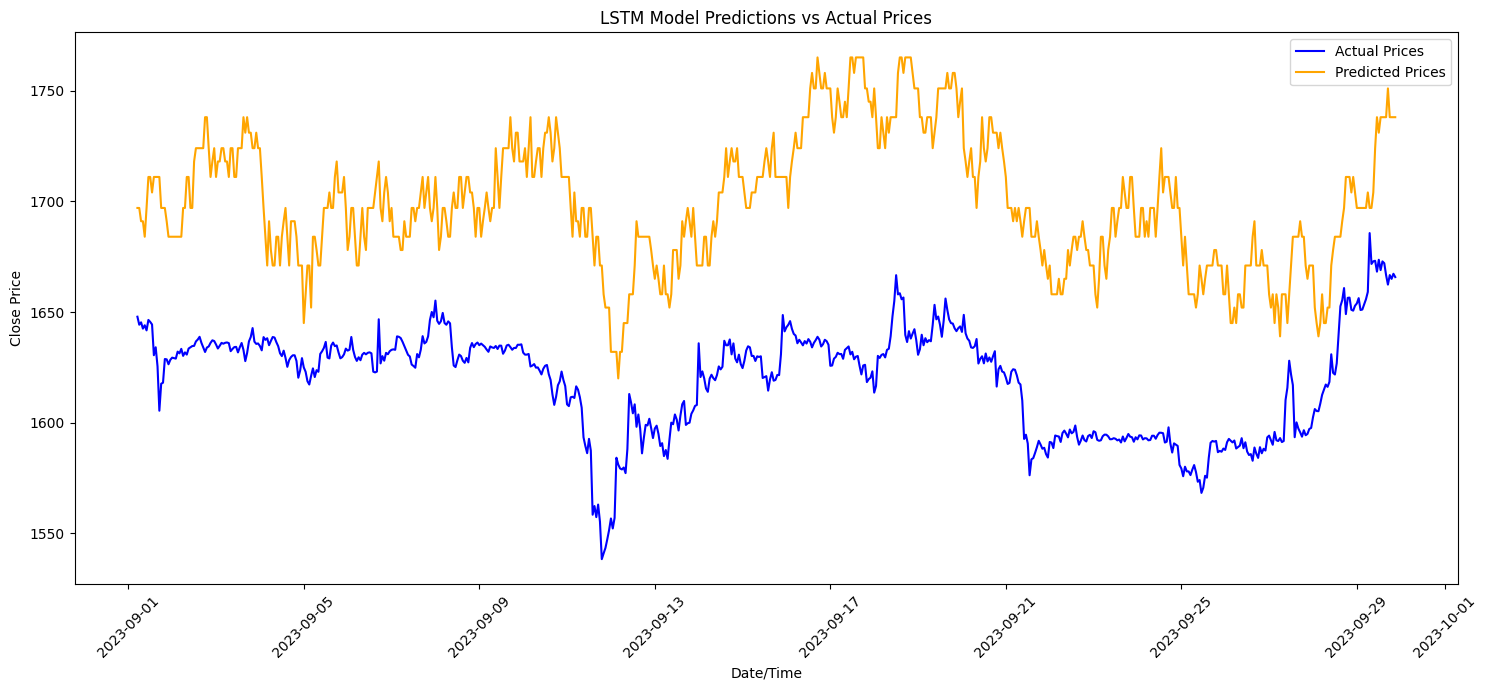

In [15]:
# Plotting the results
plt.figure(figsize=(15, 7))
plt.plot(timestamps, actual_prices, label='Actual Prices', color='blue')
plt.plot(timestamps, predicted_prices, label='Predicted Prices', color='orange')
plt.xlabel('Date/Time')
plt.ylabel('Close Price')

plt.title('LSTM Model Predictions vs Actual Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()

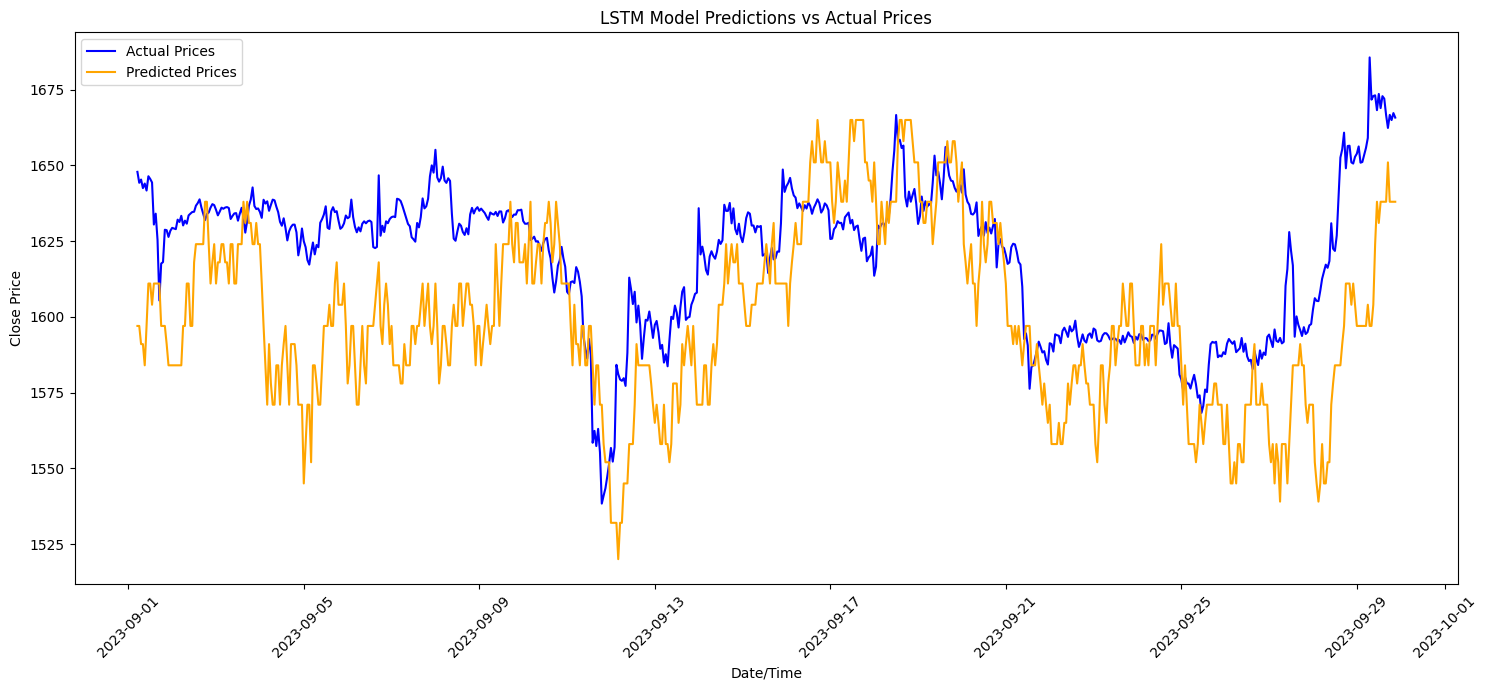

In [16]:
# Plotting the results
plt.figure(figsize=(15, 7))
plt.plot(timestamps, actual_prices, label='Actual Prices', color='blue')
plt.plot(timestamps, test, label='Predicted Prices', color='orange')
plt.xlabel('Date/Time')
plt.ylabel('Close Price')

plt.title('LSTM Model Predictions vs Actual Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()

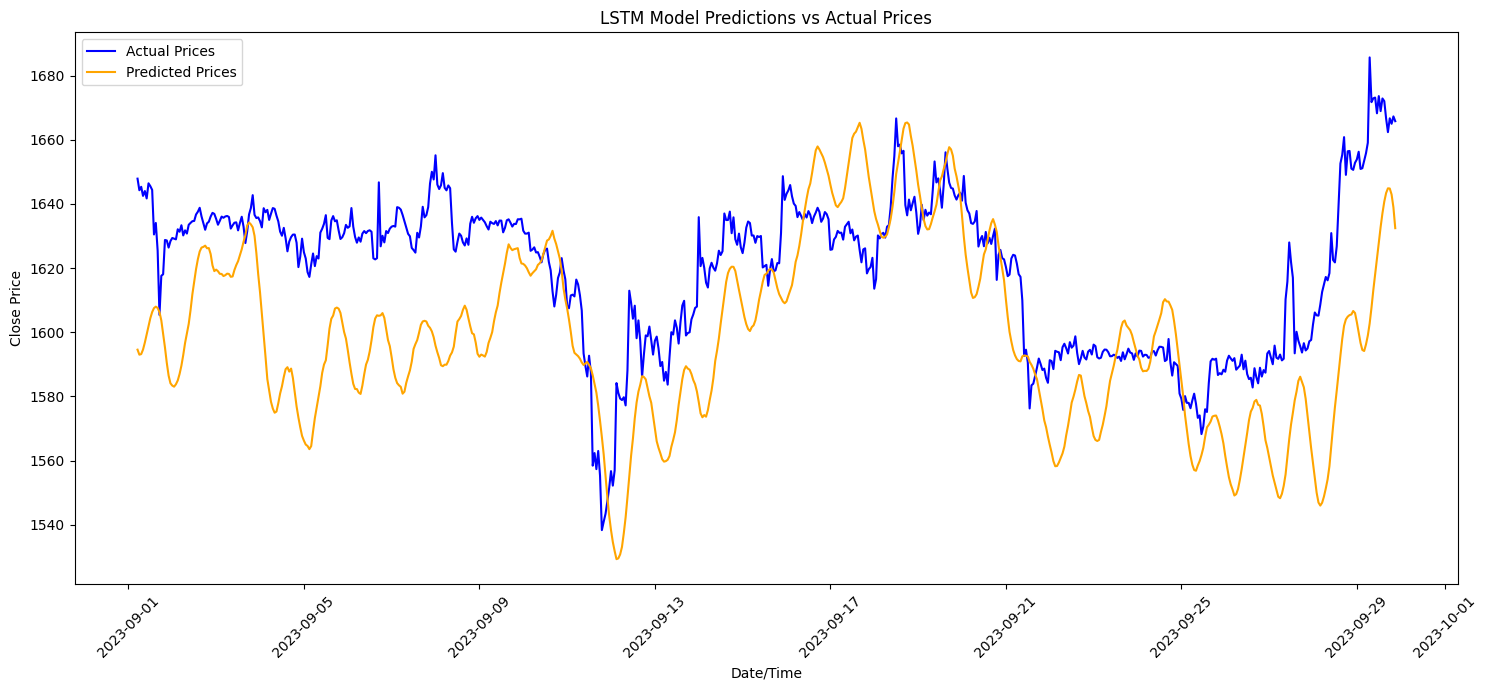

In [17]:
# with smoothing
from scipy.signal import savgol_filter

test_smooth = savgol_filter(test, 25, 4) # window size 51, polynomial order 3

# Plotting the results
plt.figure(figsize=(15, 7))
plt.plot(timestamps, actual_prices, label='Actual Prices', color='blue')
plt.plot(timestamps, test_smooth, label='Predicted Prices', color='orange')
plt.xlabel('Date/Time')
plt.ylabel('Close Price')

plt.title('LSTM Model Predictions vs Actual Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()

441/441 [==============================] - 2s 5ms/step


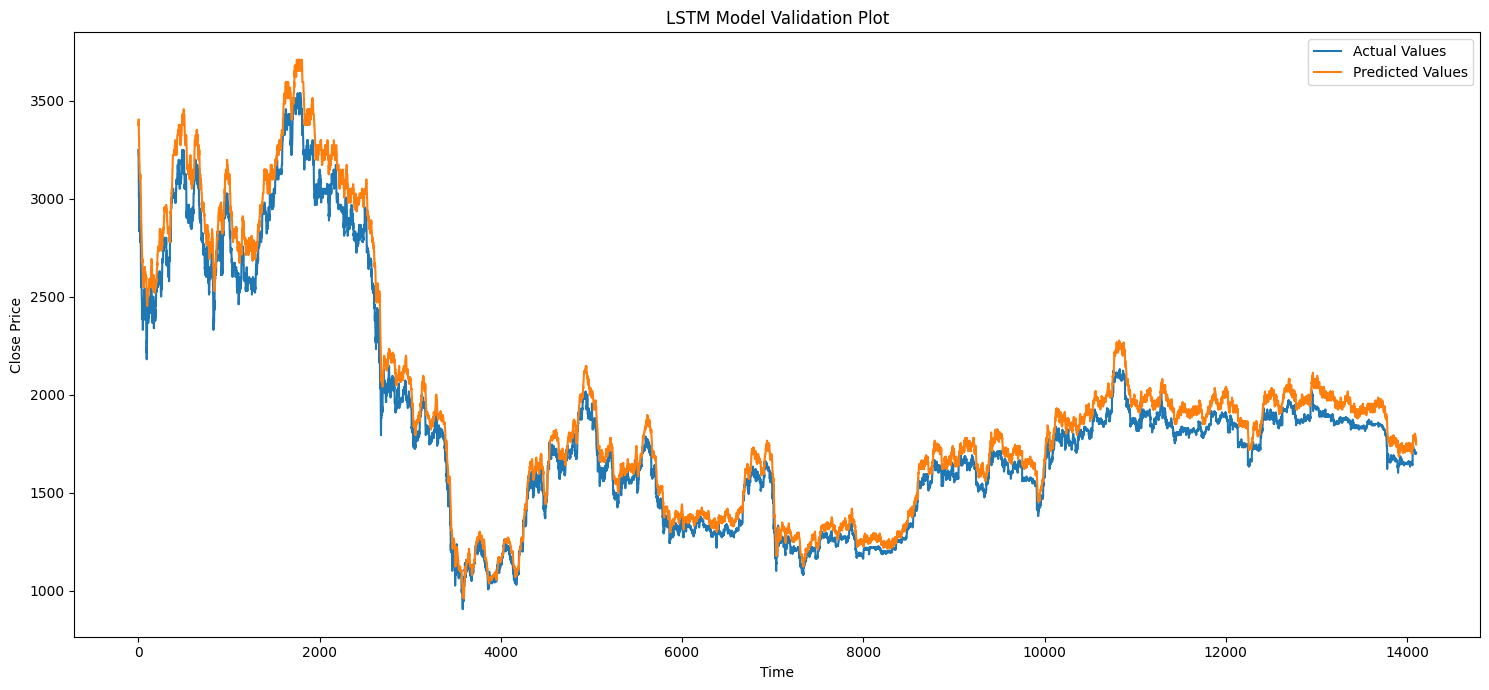

In [44]:
## Plotting the validation set 

y_pred = model.predict(X_val)

y_val_true = np.expm1(y_val)
y_pred_true = np.expm1(y_pred)

plt.figure(figsize=(15, 7))
plt.plot(y_val_true, label='Actual Values')
plt.plot(y_pred_true, label='Predicted Values')
plt.title('LSTM Model Validation Plot')
plt.xlabel('Time')
plt.ylabel('Close Price')
#plt.yscale('log')
plt.legend()
plt.tight_layout() 